In [ ]:
!pip install causal-conv1d>=1.2.0
!pip install mamba-ssm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.0-cp312-cp312-linux_x86_64.whl size=470617717 sha256=11e29d2a22d544a172175c47153612835d59ccff17a3b6c3010a61eafcb738b0
  Stored in directory: /root/.cache/pip/wheels/4c/4c/6f/d6add86ebe5c3dbd407ad3b593ecb31cda9adf70801387df4a
Successfully built mamba-ssm


In [ ]:
!pip install fvcore iopath

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=b86dbfe2f85266f2125b16eef133d379eb2f65be1c1db692af1f2783921f24ea
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=fe5e5c1dbf152e29ed2588e72aaaa247dc45577f5d6d76a3a378c60fdd4016fd
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [ ]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm matplotlib seaborn scikit-learn tqdm pandas

In [ ]:
import os
if not os.path.exists('VSSD'):
    !git clone https://github.com/YuHengsss/VSSD.git

In [ ]:
import sys
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import timm

sys.path.insert(0, os.path.abspath('./VSSD/classification'))

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type != 'cuda':
    print("CPU")
else:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 3e-4
NUM_CLASSES = 10
CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

GPU: Tesla T4


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

full_train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
full_test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

rng = np.random.RandomState(42)
train_idx = rng.choice(len(full_train_set), len(full_train_set) // 2, replace=False)
test_idx = rng.choice(len(full_test_set), len(full_test_set) // 2, replace=False)

train_ds = Subset(full_train_set, train_idx)
test_ds = Subset(full_test_set, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Данные: Train={len(train_ds)}, Test={len(test_ds)}")

Данные: Train=25000, Test=5000


In [ ]:
from models.mamba2 import VMAMBA2

# --- VSSD Micro ---
def build_vssd_micro(num_classes=10):

  model = VMAMBA2(
            in_chans=3,
            num_classes=num_classes,
            image_size=IMG_SIZE,
            embed_dim=48,
            depths=[2, 2, 8, 4],
            num_heads=[2, 4, 8, 16],
            d_state=48,
            ssd_expansion=2,
            linear_attn_duality=True,
            ssd_positive_da=True,
            attn_types=['mamba2', 'mamba2', 'mamba2', 'standard'],
            patch_size=4
        )
  return model

# --- ResNet-18 ---
def build_baseline(num_classes=10):
    return timm.create_model('resnet18', pretrained=False, num_classes=num_classes)

# Инициализация
vssd_model = build_vssd_micro(NUM_CLASSES).to(device)
baseline_model = build_baseline(NUM_CLASSES).to(device)

# Считаем параметры
v_params = sum(p.numel() for p in vssd_model.parameters()) / 1e6
b_params = sum(p.numel() for p in baseline_model.parameters()) / 1e6

print(f"   VSSD Micro Params: {v_params:.2f} M")
print(f"   ResNet-18 Params:  {b_params:.2f} M")

   VSSD Micro Params: 13.13 M
   ResNet-18 Params:  11.18 M


In [ ]:
def train_model(model, name, epochs=EPOCHS):
    print(f"\n🚀 Обучение: {name}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # История метрик
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'time': [],
        'preds': [], 'targets': [] # Для Confusion Matrix
    }

    for ep in range(epochs):
        t0 = time.time()

        # --- TRAIN ---
        model.train()
        train_loss = 0
        correct_train = 0
        total_train = 0

        pbar = tqdm(train_loader, desc=f"Ep {ep+1}/{epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            _, pred = out.max(1)
            correct_train += pred.eq(y).sum().item()
            total_train += y.size(0)

            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = 100 * correct_train / total_train

        # --- VAL ---
        model.eval()
        val_loss = 0
        correct_val = 0
        total_val = 0

        # Списки для сбора предиктов только на ПОСЛЕДНЕЙ эпохе
        epoch_preds = []
        epoch_targets = []

        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_loss += loss.item()

                _, pred = out.max(1)
                correct_val += pred.eq(y).sum().item()
                total_val += y.size(0)

                # Сохраняем для CM (только на последней эпохе)
                if ep == epochs - 1:
                    epoch_preds.extend(pred.cpu().numpy())
                    epoch_targets.extend(y.cpu().numpy())

        avg_val_loss = val_loss / len(test_loader)
        avg_val_acc = 100 * correct_val / total_val
        dt = time.time() - t0

        scheduler.step()

        # Logging
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)
        history['time'].append(dt)

        if ep == epochs - 1:
            history['preds'] = epoch_preds
            history['targets'] = epoch_targets

        print(f"Ep {ep+1}: TrAcc={avg_train_acc:.1f}% | ValAcc={avg_val_acc:.1f}% | Time={dt:.1f}s")

    return history

# Запуск
hist_vssd = train_model(vssd_model, "VSSD-Micro")
hist_base = train_model(baseline_model, "ResNet-18")


🚀 Обучение: VSSD-Micro...


Ep 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Ep 1: TrAcc=44.6% | ValAcc=59.8% | Time=404.5s


Ep 2/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Ep 2: TrAcc=63.3% | ValAcc=68.2% | Time=413.3s


...

Ep 8: TrAcc=83.6% | ValAcc=79.7% | Time=106.3s


Ep 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Ep 9: TrAcc=86.3% | ValAcc=80.6% | Time=106.3s


Ep 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Ep 10: TrAcc=88.2% | ValAcc=80.7% | Time=108.2s


## Графики обучения

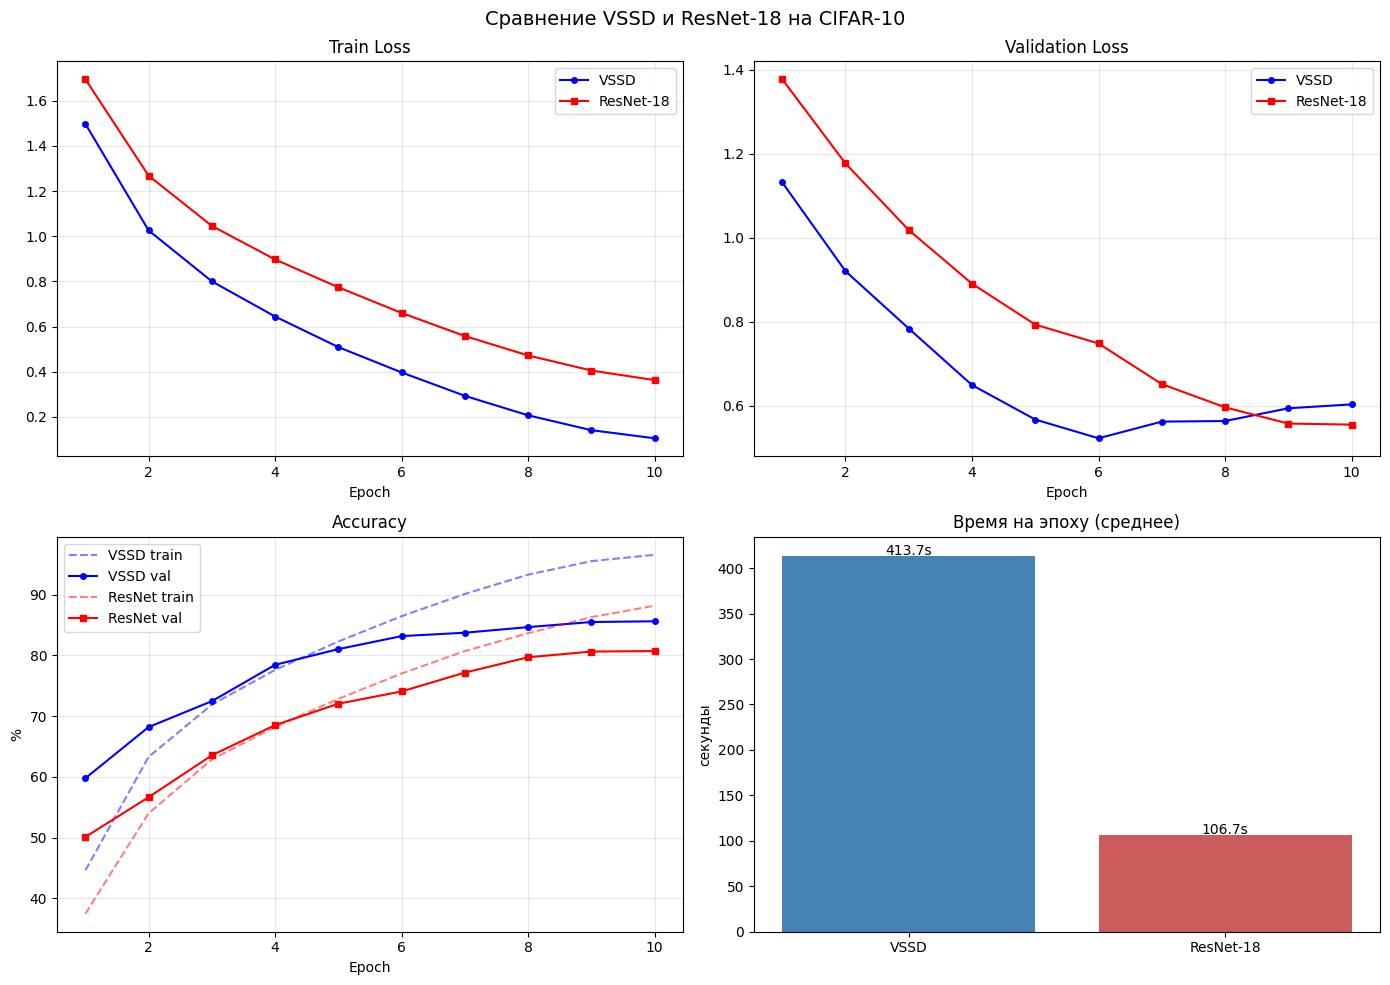

In [ ]:
# Графики обучения
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
epochs_range = range(1, EPOCHS + 1)

# Train Loss
axes[0,0].plot(epochs_range, hist_vssd['train_loss'], 'b-o', markersize=4, label='VSSD')
axes[0,0].plot(epochs_range, hist_base['train_loss'], 'r-s', markersize=4, label='ResNet-18')
axes[0,0].set_title('Train Loss')
axes[0,0].set_xlabel('Epoch')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Val Loss
axes[0,1].plot(epochs_range, hist_vssd['val_loss'], 'b-o', markersize=4, label='VSSD')
axes[0,1].plot(epochs_range, hist_base['val_loss'], 'r-s', markersize=4, label='ResNet-18')
axes[0,1].set_title('Validation Loss')
axes[0,1].set_xlabel('Epoch')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Accuracy — train пунктиром, val сплошной
axes[1,0].plot(epochs_range, hist_vssd['train_acc'], 'b--', alpha=0.5, label='VSSD train')
axes[1,0].plot(epochs_range, hist_vssd['val_acc'], 'b-o', markersize=4, label='VSSD val')
axes[1,0].plot(epochs_range, hist_base['train_acc'], 'r--', alpha=0.5, label='ResNet train')
axes[1,0].plot(epochs_range, hist_base['val_acc'], 'r-s', markersize=4, label='ResNet val')
axes[1,0].set_title('Accuracy')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('%')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Среднее время на эпоху
avg_time_vssd = np.mean(hist_vssd['time'])
avg_time_base = np.mean(hist_base['time'])
bar_colors = ['steelblue', 'indianred']
bars = axes[1,1].bar(['VSSD', 'ResNet-18'], [avg_time_vssd, avg_time_base], color=bar_colors)
axes[1,1].set_title('Время на эпоху (среднее)')
axes[1,1].set_ylabel('секунды')
for bar in bars:
    h = bar.get_height()
    axes[1,1].text(bar.get_x() + bar.get_width()/2, h + 0.3,
                   f'{h:.1f}s', ha='center', fontsize=10)

fig.suptitle('Сравнение VSSD и ResNet-18 на CIFAR-10', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## Confusion matrix для обеих моделей

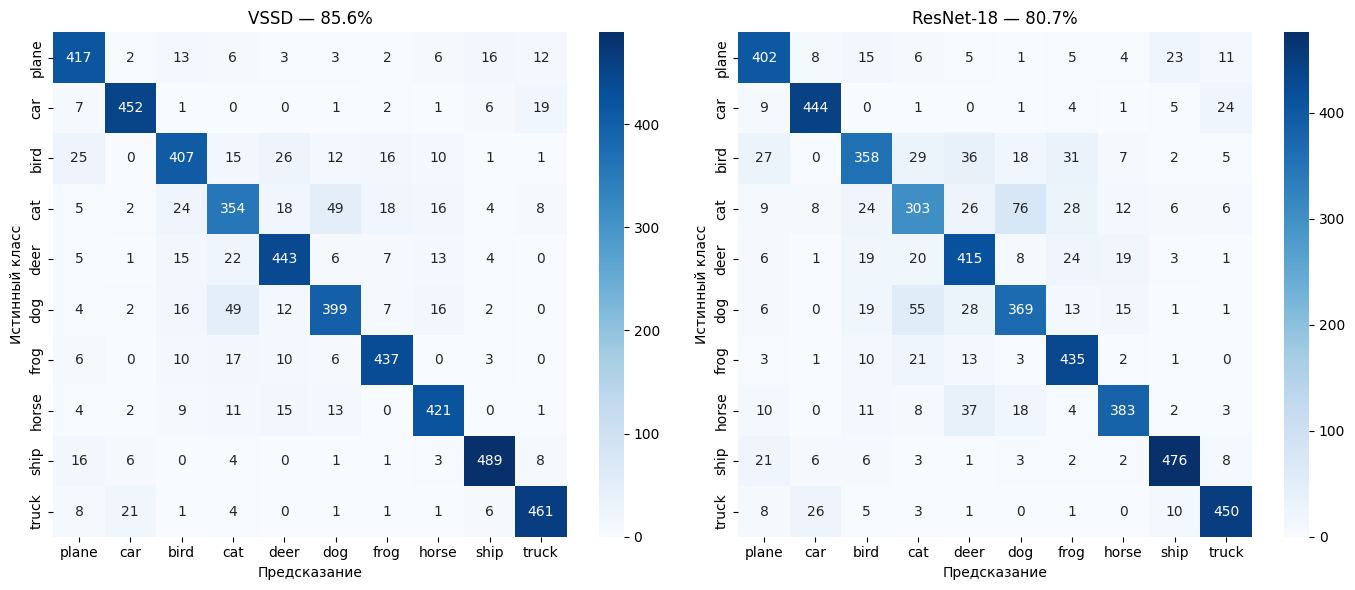


--- VSSD ---
              precision    recall  f1-score   support

       plane      0.839     0.869     0.854       480
         car      0.926     0.924     0.925       489
        bird      0.821     0.793     0.807       513
         cat      0.734     0.711     0.722       498
        deer      0.841     0.859     0.849       516
         dog      0.813     0.787     0.800       507
        frog      0.890     0.894     0.892       489
       horse      0.864     0.884     0.874       476
        ship      0.921     0.926     0.924       528
       truck      0.904     0.915     0.909       504

    accuracy                          0.856      5000
   macro avg      0.855     0.856     0.856      5000
weighted avg      0.855     0.856     0.856      5000


--- ResNet-18 ---
              precision    recall  f1-score   support

       plane      0.802     0.838     0.820       480
         car      0.899     0.908     0.903       489
        bird      0.767     0.698     0.731  

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models_data = [
    (axes[0], hist_vssd, 'VSSD'),
    (axes[1], hist_base, 'ResNet-18'),
]

for ax, hist, model_name in models_data:
    cm = confusion_matrix(hist['targets'], hist['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)

    acc = 100 * np.mean(np.array(hist['preds']) == np.array(hist['targets']))
    ax.set_title(f'{model_name} — {acc:.1f}%')
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказание')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Подробный отчет по классам
for model_name, hist in [('VSSD', hist_vssd), ('ResNet-18', hist_base)]:
    print(f'\n--- {model_name} ---')
    print(classification_report(hist['targets'], hist['preds'],
                                target_names=CLASSES, digits=3))

## Итоговая таблица

In [ ]:
best_acc_vssd = max(hist_vssd['val_acc'])
best_acc_base = max(hist_base['val_acc'])

results_df = pd.DataFrame({
    'Метрика': [
        'Параметры (M)',
        'Лучшая val accuracy (%)',
        'Финальная val accuracy (%)',
        'Минимальный val loss',
        'Среднее время на эпоху (с)',
        'Общее время обучения (мин)',
    ],
    'VSSD': [
        f'{v_params:.2f}',
        f'{best_acc_vssd:.1f}',
        f'{hist_vssd["val_acc"][-1]:.1f}',
        f'{min(hist_vssd["val_loss"]):.4f}',
        f'{avg_time_vssd:.1f}',
        f'{sum(hist_vssd["time"])/60:.1f}',
    ],
    'ResNet-18': [
        f'{b_params:.2f}',
        f'{best_acc_base:.1f}',
        f'{hist_base["val_acc"][-1]:.1f}',
        f'{min(hist_base["val_loss"]):.4f}',
        f'{avg_time_base:.1f}',
        f'{sum(hist_base["time"])/60:.1f}',
    ],
})

print('\nРезультаты эксперимента:')
print(results_df.to_string(index=False))

# Кто победил
if best_acc_vssd > best_acc_base:
    winner, loser = 'VSSD', 'ResNet-18'
    w_acc, l_acc = best_acc_vssd, best_acc_base
else:
    winner, loser = 'ResNet-18', 'VSSD'
    w_acc, l_acc = best_acc_base, best_acc_vssd


Результаты эксперимента:
                   Метрика   VSSD ResNet-18
             Параметры (M)  13.13     11.18
   Лучшая val accuracy (%)   85.6      80.7
Финальная val accuracy (%)   85.6      80.7
      Минимальный val loss 0.5225    0.5550
Среднее время на эпоху (с)  413.7     106.7
Общее время обучения (мин)   69.0      17.8


# Выводы

1. Качество: VSSD показал значительное превосходство над ResNet-18, увеличив точность (Accuracy) на 4.9% (85.6% против 80.7%) при сопоставимом количестве параметров (~11–13M).
2. Эффективность: VSSD лучше извлекает признаки и учитывает глобальный контекст изображения, что подтверждается более быстрым падением Loss и меньшим количеством ошибок в сложных классах.
3. Скорость: Главный минус VSSD - это долгое обучение. Модель оказалась в 3.9 раза медленнее ResNet-18.

В общем, VSSD - это отличная замена CNN: точность ощутимо выше, хоть и обучается она пока дольше. Мне кажется, на высоком разрешении разница между моделями стала бы еще более очевидной. Также потенциал VSSD явно виден в работе с большими объемами данных - судя по тому, как быстро она переобучается на маленьком датасете, ее потолок гораздо выше, чем у ResNet, и на больших выборках она покажет себя еще лучше.